My Octave Notebook 
============

Interact with Octave and the statistics-resampling package online in Jupyter Notebook with Binder. All commands are interpreted by Octave.  Since this is a [MetaKernel](https://github.com/Calysto/metakernel), a standard set of magics are available.  Help on commands is available using the `%help` magic or using `?` with a command. For the best experience, run this notebook in [Jupyter Lab](https://mybinder.org/v2/gh/acpennlab/statistics-resampling-online/master?labpath=statistics-resampling.ipynb). 

The code cells and their output below illustrate some examples of loading data and then performing analysis using functions from the **statistics-resampling** package. Follow the links in the **Quick start** section of the [README page](https://gnu-octave.github.io/statistics-resampling/readme.html), or on the [Function reference page](https://gnu-octave.github.io/statistics-resampling/function_reference), to find further examples. The example data files provided, **data1.tsv** and **data2.csv**, can be edited directly in this instance of JupyterLab. 

The statistics-resampling package already comes installed and loaded at **statistics-resampling-online**. Visit [GNU Octave Packages](https://gnu-octave.github.io/packages/) to see what other packages are available and how to install them. To load a newly installed package called `<package-name>`, use the command `pkg load <package-name>`. To preview demonstration number `X` of a function called `<function-name>`, use the command `demo ('<function-name>', X)`. To get more information about a particular function called `<function-name>`, use the command `help <function-name>`. Note that the **parallel** package cannot be installed at **statistics-resampling-online**, and that additions to the binder environment may be required to build or run some other Octave packages.

Some Octave packages come already installed and in this statistics-resampling-online Binder environment. If you were running Octave on your own machine, you would need to install and load the statistics-resampling package first by running the code in the following two cells:

In [2]:
# Run this command once to install the package
pkg install -forge statistics-resampling 

The statistics-resampling package was installed into the directory:
/home/jovyan/.local/share/octave/api-v58/packages/statistics-resampling-5.7.1
License and copyright information can be found at:
https://github.com/gnu-octave/statistics-resampling/blob/master/COPYING


In [3]:
# Run this command in each new Octave session
pkg load statistics-resampling

Run the code in the next code cell if you wish to know:
1) The version of GNU Octave that you are running
2) What packages (and their version) are already installed (and loaded*) here
3) More information about the statistics-resampling package

In [4]:
ver('Octave');
pkg list;
pkg describe -verbose statistics-resampling

----------------------------------------------------------------------
GNU Octave Version: 8.3.0 (hg id: 6fc591af58ba)
GNU Octave License: GNU General Public License
Operating System: Linux 6.8.0-134-generic #134-Ubuntu SMP PREEMPT_DYNAMIC Fri Jun 26 18:43:11 UTC 2026 x86_64
----------------------------------------------------------------------
Package Name           | Version | Installation directory
-----------------------+---------+-----------------------
                coder  |   1.9.1 | .../octave/api-v58/packages/coder-1.9.1
              control  |   4.0.0 | .../octave/api-v58/packages/control-4.0.0
       data-smoothing  |   1.3.0 | .../api-v58/packages/data-smoothing-1.3.0
            dataframe  |   1.2.0 | .../octave/api-v58/packages/dataframe-1.2.0
               fileio  |   1.2.2 | .../octave/api-v58/packages/fileio-1.2.2
                   ga  |  0.10.4 | .../share/octave/api-v58/packages/ga-0.10.4
                   io *|   2.6.4 | .../share/octave/api-v58/packages/io-2.

In [5]:
[~, mutation]     = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'B2:B251');
[~, transfection] = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'C2:C251');
outcomes          = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'H2:R251');

disp (size (outcomes))

   250    11


Columns H–R from `n2a_mutant.xlsx`, in order as loaded into the outcomes matrix:

| Column | Variable | Description | Unit |
|--------|----------|-------------|------|
| 1 | peakNMDA | NMDA peak current amplitude | pA |
| 2 | decayNMDA | NMDA decay time constant (decay tau) | ms |
| 3 | chargeNMDA | NMDA charge transfer | pC |
| 4 | dt50NMDA | NMDA time to half-decay | ms |
| 5 | fwhmNMDA | NMDA full-width at half-maximum | ms |
| 6 | peakAMPA | AMPA peak current amplitude | pA |
| 7 | decayAMPA | AMPA decay time constant | ms |
| 8 | chargeAMPA | AMPA charge transfer | pC |
| 9 | riseAMPA | AMPA rise time | ms |
| 10 | dt50AMPA | AMPA time to half-decay | ms |
| 11 | fwhmAMPA | AMPA full-width at half-maximum | ms |

In [6]:
outcomes_log = log (outcomes);

In [7]:
plus_idx  = strcmp (transfection, '+');
minus_idx = strcmp (transfection, '-');

outcomes_diff = outcomes_log(plus_idx, :) - outcomes_log(minus_idx, :);
mutation_diff = mutation(plus_idx);

disp (size (outcomes_diff))
disp (unique (mutation_diff,'stable'))

   125    11
{
  [1,1] = WT
  [2,1] = K669N
  [3,1] = L812M
  [4,1] = C436R
  [5,1] = T531M
  [6,1] = R518H
}


In [8]:
# sanity check
for m = {'C436R','K669N','L812M','R518H','T531M','WT'}
  fprintf ('%s: %d pairs\n', m{1}, sum (strcmp (mutation_diff, m{1})))
end

# WT differences should be close to 0
WT_idx = strcmp (mutation_diff, 'WT');
disp (mean (outcomes_diff(WT_idx, :)))

C436R: 17 pairs
K669N: 29 pairs
L812M: 27 pairs
R518H: 17 pairs
T531M: 17 pairs
WT: 18 pairs
 Columns 1 through 6:

  -2.3472e-01  -2.4666e-02  -2.7401e-01   1.3170e-01   1.2259e-01  -1.1105e-01

 Columns 7 through 11:

   1.2762e-01   1.7635e-02  -8.7821e-03  -6.9755e-02  -2.0635e-02



MODEL FORMULA (based on Wilkinson's notation):

Y ~ 1 + X1

MODEL COEFFICIENTS

name                                   coeff       CI_lower    CI_upper    p-val
--------------------------------------------------------------------------------
(Intercept)                            -0.2347     -0.4574     -0.01200     .042
X1_1                                   -0.1445     -0.4409     +0.1519      .336
X1_2                                   -0.09552    -0.3729     +0.1819      .489
X1_3                                   -0.2274     -0.5738     +0.1190      .189
X1_4                                   -0.2257     -0.4890     +0.03767     .088
X1_5                                   -0.3001     -0.6663     +0.06611     .113

mdl =

  scalar structure containing the fields:

    method = Wild bootstrap-t
    name =
    {
      [1,1] = (Intercept)
      [1,2] = X1_1
      [1,3] = X1_2
      [1,4] = X1_3
      [1,5] = X1_4
      [1,6] = X1_5
    }

    estimate =

      -0.234719
      -0.1444

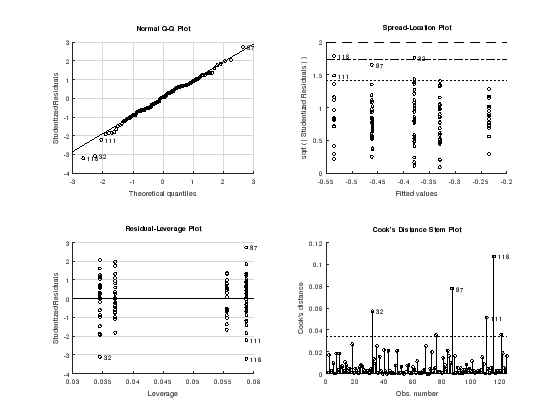

In [9]:
mdl = bootlm (outcomes_diff(:,1), {mutation_diff})

In [10]:
mdl

mdl =

  scalar structure containing the fields:

    method = Wild bootstrap-t
    name =
    {
      [1,1] = (Intercept)
      [1,2] = X1_1
      [1,3] = X1_2
      [1,4] = X1_3
      [1,5] = X1_4
      [1,6] = X1_5
    }

    estimate =

      -0.234719
      -0.144479
      -0.095516
      -0.227388
      -0.225668
      -0.300110

    CI_lower =

      -0.4574
      -0.4409
      -0.3729
      -0.5738
      -0.4890
      -0.6663

    CI_upper =

      -0.012001
       0.151926
       0.181887
       0.119042
       0.037666
       0.066114

    pval =

       0.042177
       0.335873
       0.488966
       0.189399
       0.088010
       0.112900

    fpr =

       0.2663
       0.4990
       0.5000
       0.4614
       0.3677
       0.4010

    N = 125
    prior = [](0x0)
    levels =
    {
      [1,1] =
      {
        [1,1] = WT
        [2,1] = K669N
        [3,1] = L812M
        [4,1] = C436R
        [5,1] = T531M
        [6,1] = R518H
      }

    }

    contrasts =
    {
   

In [11]:
animal_raw  = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'F2:F251');
animal_diff = animal_raw(plus_idx);

fprintf ('Unique animals: %d\n', numel (unique (animal_diff)))
disp (unique (animal_diff)')

Unique animals: 6
   1   2   3   4   5   6


In [12]:
contrast_S1 = [
  -5/6,    0,    0,    0,    0;  # WT 
  1/6,  3/5,    0,    0, -1/2;  # K669N
  1/6,  3/5,    0,    0,  1/2;  # L812M 
  1/6, -2/5, -1/3, -1/2,    0;  # C436R 
  1/6, -2/5, -1/3,  1/2,    0;  # T531M
  1/6, -2/5,  2/3,    0,    0;  # R518H
 
 
];

disp (contrast_S1)

  -0.8333        0        0        0        0
   0.1667   0.6000        0        0  -0.5000
   0.1667   0.6000        0        0   0.5000
   0.1667  -0.4000  -0.3333  -0.5000        0
   0.1667  -0.4000  -0.3333   0.5000        0
   0.1667  -0.4000   0.6667        0        0


unpen_treatment =

 Columns 1 through 8:

   0.8655   1.3827   1.2539   1.3169   1.2760   0.8616   1.0165   0.8577
   0.9089   1.4293   1.1398   1.5882   1.5509   0.8493   1.1957   0.9235
   0.7966   2.0080   1.6222   1.8763   1.8207   1.2247   0.7360   0.9247
   0.7980   2.1309   1.7729   2.3730   2.2505   1.1682   0.7737   1.0036
   0.7407   1.9909   1.2641   1.8161   1.8074   1.1167   0.8674   0.9150

 Columns 9 through 11:

   0.9850   1.1503   1.0644
   1.1525   1.1193   1.0677
   1.0203   0.9929   0.9499
   0.8890   0.8737   0.8723
   1.0108   1.0082   1.0106



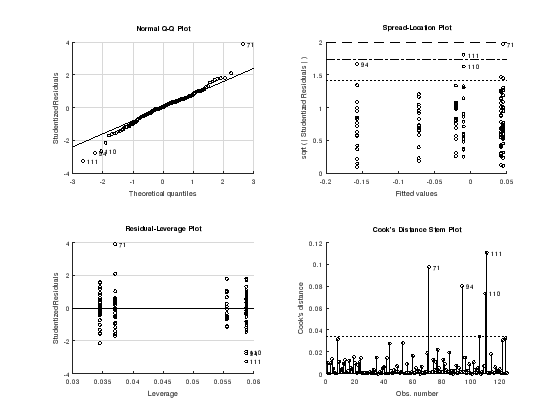

In [13]:
unpen_treatment = zeros (6, 11);
for i = 1:size (outcomes_diff, 2)
  MAT_T = bootlm (outcomes_diff(:,i), {mutation_diff}, ...
                  'model', 'linear', 'display', 'on', ...
                  'contrasts', {'treatment'}, 'nboot', 0); 
  %sprintf('outcome %d', i) 
  %disp(MAT_T.b)
  unpen_treatment(:,i) = exp (MAT_T.b);
  print (sprintf ('../output/GRIN2A_outcome%d.png', i), '-dpng', '-r300')
end
unpen_treatment(1,:)=[] % remove intercept from output

In [14]:
outcome_names = {'peakNMDA','decayNMDA','chargeNMDA','dt50NMDA','fwhmNMDA', ...
                 'peakAMPA','decayAMPA','chargeAMPA','riseAMPA','dt50AMPA','fwhmAMPA'};

fprintf ('DEFF per outcome (animal-level clustering):\n')
DEFF_per_outcome = zeros (1, 11);

for i = 1:11
  [~, BS_clust] = bootlm (outcomes_diff(:,i), {mutation_diff}, ...
                           'clustid', animal_diff, 'method', 'bayes', 'prior', 'auto', ...
                           'display', 'off', 'contrasts', {contrast_S1}, 'seed', 1);
  [~, BS_iid]   = bootlm (outcomes_diff(:,i), {mutation_diff}, ...
                           'method', 'bayes', 'display', 'off', ...
                           'contrasts', {contrast_S1}, 'seed', 1);
  DEFF_per_outcome(i) = mean (deffcalc (BS_clust, BS_iid));
  fprintf ('  %-12s: %.3f\n', outcome_names{i}, DEFF_per_outcome(i));
end

Deff = mean (DEFF_per_outcome);
fprintf ('\nMean DEFF used in bootridge: %.3f\n', Deff)

DEFF per outcome (animal-level clustering):
  peakNMDA    : 7.503
  decayNMDA   : 11.818
  chargeNMDA  : 4.716
  dt50NMDA    : 20.877
  fwhmNMDA    : 23.418
  peakAMPA    : 7.215
  decayAMPA   : 5.335
  chargeAMPA  : 8.573
  riseAMPA    : 1.461
  dt50AMPA    : 6.001
  fwhmAMPA    : 5.562

Mean DEFF used in bootridge: 9.316


In [15]:
% Obtain design matrix (MAT.X) for custom orthogonal contrasts applied to this 
% model and the hypothesis matrix (MAT.L)to calculate estimated marginal means
MAT = bootlm (outcomes_diff(:,1), {mutation_diff}, ...
              'model', 'linear', 'display', 'off', ...
              'contrasts', {contrast_S1}, 'nboot', 0, 'dim', 1);



 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 125

 Design effect (Deff): 9.32

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 10.0174

 Predicted R-squared: 0.089 (8.9%)

 Bootstrap optimized ridge tuning constant (lambda, Deff-adjusted): 0.662452

 Effective residual degrees of freedom (df_lambda): 119.

 Residual variances (range, Deff-inflated):  [0.707, 3.69]

 Inferential degrees of freedom (df_t, Deff-adjusted): 7.66
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.03576      -0.7670       +0.7359  
 1             3             +0.7272       -0.05440      +0.9562  
 

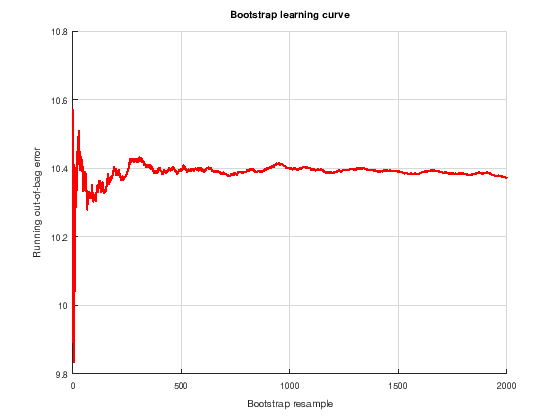

In [16]:
% Get statistics for the contrast coefficients (hypothesis testing)
% Use the empirically estimated design effect 
tic
bootridge (outcomes_diff, MAT.X, '*', 1999, 0.05, [], Deff);
toc
ridge_coeff = ans;

In [17]:
ridge_coeff.BF10

ans =

 Columns 1 through 8:

      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN
   0.2348   1.1691   0.2582   1.8596   2.4535   0.2043   0.2127   0.2072
   0.1736   0.6371   0.1986   0.6594   0.9189   0.2342   0.3302   0.1584
   0.2384   0.2367   0.2701   0.2721   0.2619   0.2370   0.2493   0.2362
   0.2689   0.2724   0.2715   0.3490   0.3537   0.2697   0.2704   0.2714
   0.2144   0.2141   0.2167   0.2816   0.3137   0.2128   0.2348   0.2154

 Columns 9 through 11:

      NaN      NaN      NaN
   0.2039   0.2044   0.2040
   0.1667   0.1952   0.1916
   0.2378   0.2399   0.2502
   0.2817   0.2796   0.2773
   0.2355   0.2133   0.2127



In [18]:
RTAB = ridge_coeff.RTAB;
disp (min (RTAB(:,3)));
disp (max (RTAB(:,3)));

-0.1715
0.9841



 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 125

 Design effect (Deff): 9.32

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 10.0174

 Predicted R-squared: 0.089 (8.9%)

 Bootstrap optimized ridge tuning constant (lambda, Deff-adjusted): 0.662452

 Effective residual degrees of freedom (df_lambda): 119.

 Residual variances (range, Deff-inflated):  [0.707, 3.69]

 Inferential degrees of freedom (df_t, Deff-adjusted): 7.66
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.03576      -0.7670       +0.7359  
 1             3             +0.7272       -0.05440      +0.9562  
 

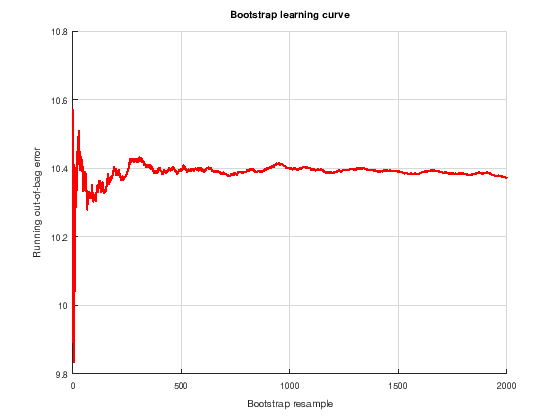

In [19]:
% Get Credible intervals for the estimated marginal means
tic
bootridge (outcomes_diff, MAT.X, '*', 1999, 0.05, MAT.L, Deff);
toc
ridge_emm = ans;

In [20]:
% Get hypothesis matrix for treatment versus control comparisons
MAT_T = bootlm (outcomes_diff(:,1), {mutation_diff}, ...
              'model', 'linear', 'display', 'off', ...
              'contrasts', {contrast_S1}, 'nboot', 0, 'dim', 1, 'posthoc', {'trt_vs_ctrl',1});
disp (MAT_T.L)

        0        0        0        0        0
   1.0000   1.0000   1.0000   1.0000   1.0000
   0.6000   0.6000  -0.4000  -0.4000  -0.4000
        0        0  -0.3333  -0.3333   0.6667
        0        0  -0.5000   0.5000        0
  -0.5000   0.5000        0        0        0



 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 125

 Design effect (Deff): 9.32

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 10.0174

 Predicted R-squared: 0.089 (8.9%)

 Bootstrap optimized ridge tuning constant (lambda, Deff-adjusted): 0.662452

 Effective residual degrees of freedom (df_lambda): 119.

 Residual variances (range, Deff-inflated):  [0.707, 3.69]

 Inferential degrees of freedom (df_t, Deff-adjusted): 7.66
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.03576      -0.7670       +0.7359  
 1             3             +0.7272       -0.05440      +0.9562  
 

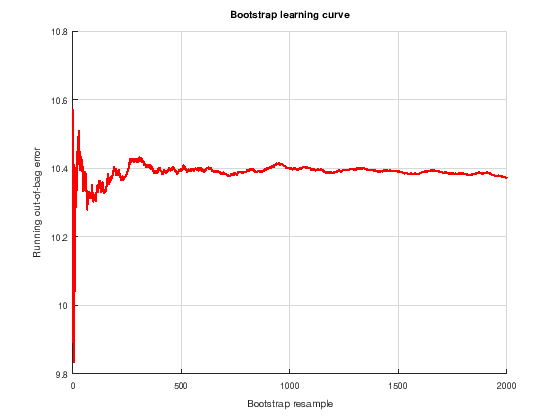

In [21]:
tic
bootridge (outcomes_diff, MAT_T.X, '*', 1999, 0.05, MAT_T.L, Deff);
toc
ridge_posthoc = ans;

In [22]:
pen_treatment = exp (ridge_posthoc.estimate)

pen_treatment =

 Columns 1 through 8:

   0.8720   1.3587   1.2386   1.2977   1.2590   0.8633   1.0205   0.8624
   0.9137   1.4026   1.1309   1.5520   1.5170   0.8517   1.1912   0.9255
   0.8037   1.9538   1.5910   1.8345   1.7821   1.2147   0.7456   0.9290
   0.8050   2.0645   1.7276   2.2810   2.1692   1.1626   0.7809   1.0023
   0.7503   1.9371   1.2560   1.7753   1.7666   1.1136   0.8703   0.9192

 Columns 9 through 11:

   0.9870   1.1463   1.0635
   1.1466   1.1166   1.0664
   1.0172   0.9909   0.9507
   0.8952   0.8800   0.8784
   1.0094   1.0064   1.0087



In [23]:
fprintf ('=== ESTIMATED MARGINAL MEANS AS %% OF WT ===\n')
fprintf ('(penalised = ridge, unpenalised = OLS bootlm)\n\n')

for o = 1:size (pen_treatment, 2)
  fprintf ('--- %s ---\n', outcome_names{o})
  fprintf ('%-8s  %16s  %16s\n', 'Mutation', 'Penalised (%WT)', 'Unpenalised (%WT)')
  fprintf ('%s\n', repmat ('-', 1, 44))
  for r = 1:size (pen_treatment, 1)
    fprintf ('%-8s  %14.1f%%  %14.1f%%\n', mdl.levels{1}{r+1}, ...
             pen_treatment(r,o) * 100, ...
             unpen_treatment(r,o) * 100);
  end
  fprintf ('\n')
end

=== ESTIMATED MARGINAL MEANS AS % OF WT ===
(penalised = ridge, unpenalised = OLS bootlm)

--- peakNMDA ---
Mutation   Penalised (%WT)  Unpenalised (%WT)
--------------------------------------------
K669N               87.2%            86.5%
L812M               91.4%            90.9%
C436R               80.4%            79.7%
T531M               80.5%            79.8%
R518H               75.0%            74.1%

--- decayNMDA ---
Mutation   Penalised (%WT)  Unpenalised (%WT)
--------------------------------------------
K669N              135.9%           138.3%
L812M              140.3%           142.9%
C436R              195.4%           200.8%
T531M              206.5%           213.1%
R518H              193.7%           199.1%

--- chargeNMDA ---
Mutation   Penalised (%WT)  Unpenalised (%WT)
--------------------------------------------
K669N              123.9%           125.4%
L812M              113.1%           114.0%
C436R              159.1%           162.2%
T531M              17

In [24]:
contrast_names = {'A: WT vs Mut', 'B: LOF vs GOF', 'C: LOF2 vs LOF1', 'D: LOF2', 'E: GOF1'};
outcome_names  = {'peakNMDA','decayNMDA','chargeNMDA','dt50NMDA','fwhmNMDA', ...
                  'peakAMPA','decayAMPA','chargeAMPA','riseAMPA','dt50AMPA','fwhmAMPA'};

fprintf ('\n%s\n', repmat('=', 1, 70))
fprintf ('RESULTS SUMMARY\n')
fprintf ('%s\n\n', repmat('=', 1, 70))

for c = 1:5
  fprintf ('Contrast %s\n', contrast_names{c})
  fprintf ('%-14s  %8s  %10s  %8s\n', 'Outcome', 'Coef', 'BF10', 'SS%')
  fprintf ('%s\n', repmat('-', 1, 46))
  for o = 1:11
    coef = ridge_coeff.coefficient(c+1, o); 
    bf   = ridge_coeff.BF10(c+1, o);
    ss   = ridge_coeff.stability(c+1, o) * 100;
    flag = '';
    if bf > 10 && ss > 97.5;  flag = '***'; end
    if bf > 3  && ss > 97.5 && strcmp(flag,''); flag = '**'; end
    if ss > 97.5 && strcmp(flag,''); flag = '*ss'; end
    fprintf ('%-14s  %8.3f  %10.1f  %7.1f%%  %s\n', ...
             outcome_names{o}, coef, bf, ss, flag)
  end
  fprintf ('\n')
end
fprintf ('*** CI + BF + SS all clear | ** BF + SS | *ss SS only\n')


RESULTS SUMMARY

Contrast A: WT vs Mut
Outcome             Coef        BF10       SS%
----------------------------------------------
peakNMDA          -0.190         0.2     70.6%  
decayNMDA          0.540         1.2     87.3%  
chargeNMDA         0.315         0.3     73.6%  
dt50NMDA           0.541         1.9     87.3%  
fwhmNMDA           0.514         2.5     87.3%  
peakAMPA           0.029         0.2     52.6%  
decayAMPA         -0.097         0.2     63.8%  
chargeAMPA        -0.076         0.2     57.2%  
riseAMPA           0.008         0.2     50.9%  
dt50AMPA           0.023         0.2     53.1%  
fwhmAMPA          -0.009         0.2     51.4%  

Contrast B: LOF vs GOF
Outcome             Coef        BF10       SS%
----------------------------------------------
peakNMDA           0.127         0.2     67.4%  
decayNMDA         -0.363         0.6     87.3%  
chargeNMDA        -0.245         0.2     74.3%  
dt50NMDA          -0.318         0.7     87.3%  
fwhmNMDA     

In [ ]:
pair = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'D2:D251');

In [ ]:
bootlm (outcomes_log(:,2), {mutation, transfection, pair}, ...
                    'model', [1 0 0; 0 1 0; 0 0 1; 1 1 0], 'display', 'on', ...
                    'method', 'bayes', 'prior', 1, ...
                    'contrasts', {contrast_S1, 'simple', 'simple'}, 'nboot', 199);
# Note that the contrast coefficients have the opposite sign due to + being the reference rather than the -.

In [ ]:
MAT_I = bootlm (outcomes_log(:,2), {mutation, transfection, pair}, ...
                    'model', [1 0 0; 0 1 0; 0 0 1; 1 1 0], 'display', 'on', ...
                    'contrasts', {contrast_S1, 'simple', 'effect'}, 'nboot', 0);

In [ ]:
% Use a smaller number of bootstrap resamples to prevent the Binder kernel instance from timing out
% Use the estimate of Deff from the simpler model on the variant-WT differences
tic
bootridge (outcomes_log, MAT_I.X, '*', 499, 0.05, [], Deff);
toc
ridge_int = ans;

In [ ]:
fprintf ('\nDifferences model (last 5 rows = mutation contrasts for transfected vs untransfected):\n')
disp (exp(ridge_coeff.coefficient(end-4:end, :)))

fprintf ('\nInteraction model (last 5 rows = mutation x transfection for outcomes):\n')
% Note that we multiple by -1 to get the same sign to compare to the same transfection reference level
disp (exp(-1 * ridge_int.coefficient(end-4:end, :)))

% This shows that the simpler model (analysing the transfected vs untransfected outcomes with a single predictor) 
% is effective at capturing shrunken effect sizes we are interested in and is far more computationally efficient at doing  
% so than analysing with separate predictors for mutation x transfection interaction and cell pairs as a blocking factor.
% Note the degrees of freedom in the interaction model arising from including the blocking factor as a fixed effect. 

In [ ]:
mut_levels_stable = unique (mutation_diff, 'stable');

unpen_emm = zeros (6, 11);
for i = 1:11
  tmp = bootlm (outcomes_diff(:,i), {mutation_diff}, ...
                'contrasts', {contrast_S1}, 'dim', 1, 'nboot', 0, 'display', 'off');
  unpen_emm(:,i) = tmp.estimate;
end

pen_pct_unt   = exp (ridge_emm.estimate) * 100;   # penalised
unpen_pct_unt = exp (unpen_emm)          * 100;   # unpenalised (OLS)

fprintf ('=== PERCENTAGE OF UNTRANSFECTED ===\n')
fprintf ('Ridge and OLS predicted group means, no WT normalisation\n')
fprintf ('Comparable to Elmasri et al. Fig 2 panels (biii, ciii)\n\n')

for o = 1:11
  fprintf ('--- %s ---\n', outcome_names{o})
  fprintf ('%-8s  %14s  %14s\n', 'Mutation', 'Ridge (%unt.)', 'Linear (%unt.)')
  fprintf ('%s\n', repmat ('-', 1, 40))
  for r = 1:6
    fprintf ('%-8s  %12.1f%%  %12.1f%%\n', ...
             mut_levels_stable{r}, pen_pct_unt(r,o), unpen_pct_unt(r,o));
  end
  fprintf ('\n')
end

In [ ]:
fprintf ('=== CONTRAST COMPARISON: UNPENALISED p vs RIDGE BF10 + SS ===\n')
fprintf ('Contrasts A-E from Table S1 (Elmasri et al. 2022)\n\n')

unpen_p = zeros (6, 11);   # rows: intercept + contrasts A-E
for i = 1:11
  [unpen_stats] = bootlm (outcomes_diff(:,i), {mutation_diff}, ...
                           'contrasts', {contrast_S1}, 'display', 'off', ...
                           'method', 'wild', 'nboot', 999, 'seed', 1);
  unpen_p(:,i) = unpen_stats.p;
end

contrast_letters = {'A','B','C','D','E'};
contrast_labels  = {'A: WT vs Mut', 'B: LOF vs GOF', ...
                    'C: LOF2 vs LOF1', 'D: LOF2', 'E: GOF1'};

for o = 1:11
  fprintf ('--- %s ---\n', outcome_names{o})
  fprintf ('%-18s  %10s  %10s  %8s\n', 'Contrast', 'p (unpenn)', 'BF10', 'SS%')
  fprintf ('%s\n', repmat ('-', 1, 52))
  for c = 1:5
    p_val  = unpen_p(c+1, o);       # +1 to skip intercept row
    bf_val = ridge_coeff.BF10(c+1, o);
    ss_val = ridge_coeff.stability(c+1, o) * 100;

    # significance flag for p-value
    if    p_val < 0.001; pflag = '***';
    elseif p_val < 0.01; pflag = '**';
    elseif p_val < 0.05; pflag = '*';
    else;                pflag = '';
    end

    # flag for ridge (same scheme as before)
    if bf_val > 10 && ss_val > 97.5;           rflag = '***';
    elseif bf_val > 3 && ss_val > 97.5;        rflag = '**';
    elseif ss_val > 97.5;                      rflag = '*ss';
    else;                                       rflag = '';
    end

    fprintf ('%-18s  %8.4f %-3s  %10.1f  %7.1f%%  %-4s\n', ...
             contrast_labels{c}, p_val, pflag, bf_val, ss_val, rflag);
  end
  fprintf ('\n')
end
fprintf ('Unpen: *** p<0.001 ** p<0.01 * p<0.05\n')
fprintf ('Ridge: *** CI+BF+SS | ** BF+SS | *ss SS only\n')